# **8. Aplicación de técnicas analíticas en Seguros de viaje**

Este apartado da continuidad al proyecto de seguros de viaje explicado principalmente en Rmarkdown.

A lo largo de este cuaderno se realizará el ejercicio de aplicar las técnicas analíticas en seguros de viaje y el resumen y las conclusiones finals se mostrará en el apartado correspondiente del RMarkdown.

## **8.1. Carga de datos**

Para comenzar con el análisis lo primero es la carga de los datos.

El dataset utilizado será el mismo que en el punto 6. Análisis exploratorio (EDA). Este dataset consta de las varibales de primas así como el coste de los siniestros, el número de siniestro por cada póliza y la duración del viaje.

Para evitar un trabajo muy extenso, la parte de las causas, medios y garantías estarían fuera de este análisis.

Para empezar el análisis es necesario ubicar el fichero "Fichero_Colab.csv".


In [10]:
import pandas as pd

# Cargar el dataset 'Fichero_Colab.csv', intentando con el separador de punto y coma
df = pd.read_csv('/content/Fichero_Colab.csv', sep=';', engine='python', on_bad_lines='skip')
display(df.head()) # Se muestran las primeras 5 filas del dataframe
df.info()

,policy_number,Number_insured,Product,client,policy_client,policy_start_date,policy_start_date_Travel,End_Travel,Duracion_Viaje,City_insured,...,Prima_sin_impuestos,Prima_sin_impuestos_ni_comision,PPNC_montante,Prima_adquirida,Num_dossier,Coste_eur,Fecha_apertura,Loss_country,Nom_cause_d_intervention,Nom_detail_cause_d_intervention
0,000WEBLG2R,2,TRFT53,TRF,000WEBLG2R-TRF,2024-10-16,2024-10-31,2024-11-10,11,Mundo,...,"48,37","29,02","0,0000","48,369999999999997",0,"0,00",NaN,Sin siniestro,Sin siniestro,Sin siniestro
1,001AKHWO78,1,TRFT5G,TRF,001AKHWO78-TRF,2025-08-12,2025-08-12,2025-08-16,5,Europa,...,"7,99","4,79","0,0000","7,990000000000000",0,"0,00",NaN,Sin siniestro,Sin siniestro,Sin siniestro
2,001IYTIVS4,2,TRFT53,TRF,001IYTIVS4-TRF,2025-02-07,2025-02-08,2025-02-15,8,Mundo,...,"31,85","19,11","0,0000","31,849999999999998",0,"0,00",NaN,Sin siniestro,Sin siniestro,Sin siniestro
3,001JOEGFXJ,2,TRFT51,TRF,001JOEGFXJ-TRF,2025-02-19,2025-02-20,2025-03-31,40,Mundo,...,"82,62","49,57","0,0000","82,619999999999990",0,"0,00",NaN,Sin siniestro,Sin siniestro,Sin siniestro
4,001ZP7GZMF,4,TRFT5I,TRF,001ZP7GZMF-TRF,2025-08-01,2025-08-02,2025-08-07,6,Europa,...,"44,21","26,52","0,0000","44,210000000000001",0,"0,00",NaN,Sin siniestro,Sin siniestro,Sin siniestro


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312868 entries, 0 to 312867
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   policy_number                    312868 non-null  object
 1   Number_insured                   312868 non-null  int64 
 2   Product                          312868 non-null  object
 3   client                           312868 non-null  object
 4   policy_client                    312868 non-null  object
 5   policy_start_date                312868 non-null  object
 6   policy_start_date_Travel         312868 non-null  object
 7   End_Travel                       312868 non-null  object
 8   Duracion_Viaje                   312868 non-null  int64 
 9   City_insured                     312868 non-null  object
 10  Gross_written_premium            312868 non-null  object
 11  Taxes                            312868 non-null  object
 12  Comision        

### **8.2. Verificación de los datos y Cálculo de Métricas Clave**

En este apartado se va a verificar la tipolgogía de los datos para que en caso, de que fuese necesario, modificar los tipos numéricos al importar en colab.

Para ello se puede inspeccionar el dataset con df.info()


In [11]:
print("Información del DataFrame para ver los tipos de variables:")
df.info()


Información del DataFrame para ver los tipos de variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312868 entries, 0 to 312867
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   policy_number                    312868 non-null  object
 1   Number_insured                   312868 non-null  int64 
 2   Product                          312868 non-null  object
 3   client                           312868 non-null  object
 4   policy_client                    312868 non-null  object
 5   policy_start_date                312868 non-null  object
 6   policy_start_date_Travel         312868 non-null  object
 7   End_Travel                       312868 non-null  object
 8   Duracion_Viaje                   312868 non-null  int64 
 9   City_insured                     312868 non-null  object
 10  Gross_written_premium            312868 non-null  object
 11  Taxes              

Como se puede observar, existen varias columnas destinadas a cálculos numéricos (`Gross_written_premium`, `Taxes`, `Comision`, `Prima_sin_impuestos`, `Prima_sin_impuestos_ni_comision`, `PPNC_montante`, `Prima_adquirida`, `Coste_eur`) son de tipo *object*.

Estas deben convertirse a un tipo numérico, manejando los posibles valores no numéricos mediante su conversión forzada a NaN y luego rellenando esos NaN con 0. De igual manera, `policy_start_date_Travel`, `End_Travel` y `Fecha_apertura` deben convertirse en objetos *datetime*, para tener un buen manejo de los datos.


In [12]:
import numpy as np

#lista de columnas numéricas
numeric_cols = [
    'Gross_written_premium',
    'Taxes',
    'Comision',
    'Prima_sin_impuestos',
    'Prima_sin_impuestos_ni_comision',
    'PPNC_montante',
    'Prima_adquirida',
    'Coste_eur',
    'Num_dossier',
    'Number_insured'
]

for col in numeric_cols:

    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

    df[col] = df[col].fillna(0)

# Convertir fechas
date_cols = ['policy_start_date_Travel', 'End_Travel', 'Fecha_apertura']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#'dias_contrato' y 'Duracion_Viaje' son numéricos pero por confirmar
df['dias_contrato'] = pd.to_numeric(df['dias_contrato'], errors='coerce').fillna(0).astype(int)
df['Duracion_Viaje'] = pd.to_numeric(df['Duracion_Viaje'], errors='coerce').fillna(0).astype(int)

# Convertir 'anio_compra' a tipo numérico (int) para permitir el filtrado por año
df['anio_compra'] = pd.to_numeric(df['anio_compra'], errors='coerce').fillna(0).astype(int)

# Calculate key ratios

df['siniestro_ocurrido'] = (df['Coste_eur'] > 0).astype(int)

# Ratio Siniestralidad: Coste_eur / Prima_sin_impuestos


df['Coste medio'] = np.where(
    df['Num_dossier'] != 0,
    df['Coste_eur'] / df['Num_dossier'],
    0
)

print("Tipos de datos después de la conversión y primeras 5 filas con las nuevas métricas calculadas:")
df.info()
df.head()




Tipos de datos después de la conversión y primeras 5 filas con las nuevas métricas calculadas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312868 entries, 0 to 312867
Data columns (total 42 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   policy_number                    312868 non-null  object        
 1   Number_insured                   312868 non-null  int64         
 2   Product                          312868 non-null  object        
 3   client                           312868 non-null  object        
 4   policy_client                    312868 non-null  object        
 5   policy_start_date                312868 non-null  object        
 6   policy_start_date_Travel         312868 non-null  datetime64[ns]
 7   End_Travel                       312868 non-null  datetime64[ns]
 8   Duracion_Viaje                   312868 non-null  int64         
 9   City_insured       

,policy_number,Number_insured,Product,client,policy_client,policy_start_date,policy_start_date_Travel,End_Travel,Duracion_Viaje,City_insured,...,PPNC_montante,Prima_adquirida,Num_dossier,Coste_eur,Fecha_apertura,Loss_country,Nom_cause_d_intervention,Nom_detail_cause_d_intervention,siniestro_ocurrido,Coste medio
0,000WEBLG2R,2,TRFT53,TRF,000WEBLG2R-TRF,2024-10-16,2024-10-31,2024-11-10,11,Mundo,...,0.0,48.37,0,0.0,NaT,Sin siniestro,Sin siniestro,Sin siniestro,0,0.0
1,001AKHWO78,1,TRFT5G,TRF,001AKHWO78-TRF,2025-08-12,2025-08-12,2025-08-16,5,Europa,...,0.0,7.99,0,0.0,NaT,Sin siniestro,Sin siniestro,Sin siniestro,0,0.0
2,001IYTIVS4,2,TRFT53,TRF,001IYTIVS4-TRF,2025-02-07,2025-02-08,2025-02-15,8,Mundo,...,0.0,31.85,0,0.0,NaT,Sin siniestro,Sin siniestro,Sin siniestro,0,0.0
3,001JOEGFXJ,2,TRFT51,TRF,001JOEGFXJ-TRF,2025-02-19,2025-02-20,2025-03-31,40,Mundo,...,0.0,82.62,0,0.0,NaT,Sin siniestro,Sin siniestro,Sin siniestro,0,0.0
4,001ZP7GZMF,4,TRFT5I,TRF,001ZP7GZMF-TRF,2025-08-01,2025-08-02,2025-08-07,6,Europa,...,0.0,44.21,0,0.0,NaT,Sin siniestro,Sin siniestro,Sin siniestro,0,0.0


### **8.3. Análisis Descriptivo**

Realizar un análisis descriptivo de las variables numéricas clave y visualizar sus distribuciones para identificar su forma y detectar posibles valores atípicos. También, validar visualmente los patrones de riesgo para variables categóricas con respecto a `Coste_eur` y `Ratio_Siniestralidad`.


Lo primero es generar estadísticas descriptivas para las variables numéricas. Para ello se utilizará el método .describe() para obtener estas estadísticas.

Esto se justifica porque las estadísticas descriptivas permiten resumir de manera cuantitativa las características principales de los datos, ofreciendo una visión rápida de su tendencia central (media y mediana), su dispersión (desviación estándar y rango) así como la presencia de posibles valores atípicos (outliers).

En el contexto de seguros, esto es my importante para entender el comportamiento general de las primas, los costes de los siniestros y las duraciones de los viajes.

Para poder analizar mejor el dataset, se van a utilizar las siguientes variables para el estudio y comparar esta descripción por año de compra:

In [13]:
df_2023 = df[df['anio_compra'] == 2023]
df_2024 = df[df['anio_compra'] == 2024]
df_2025 = df[df['anio_compra'] == 2025]

key_numerical_vars = [
    'Duracion_Viaje',
    'Number_insured',
    'Gross_written_premium',
    'Comision',
    'Num_dossier',
    'Coste_eur',
    'Coste medio',
]


In [14]:
df_2023 = df[df['anio_compra'] == 2023]
df_2024 = df[df['anio_compra'] == 2024]
df_2025 = df[df['anio_compra'] == 2025]


In [15]:
print("\nEstadística descriptiva de df_2023:")
display(df_2023[key_numerical_vars].describe().T)


Estadística descriptiva de df_2023:


,count,mean,std,min,25%,50%,75%,max
Duracion_Viaje,98962.0,15.662668,18.834259,1.00,8.00,11.00,17.00,365.00
Number_insured,98962.0,1.931590,1.513068,1.00,1.00,2.00,2.00,92.00
Gross_written_premium,98962.0,90.828212,78.631801,2.76,40.86,66.52,123.64,1982.54
Comision,98962.0,36.054076,31.196084,0.00,15.96,26.28,48.97,791.83
Num_dossier,98962.0,0.076332,0.307467,0.00,0.00,0.00,0.00,8.00
Coste_eur,98962.0,35.928959,530.104038,0.00,0.00,0.00,0.00,63577.51
Coste medio,98962.0,31.657576,486.614728,0.00,0.00,0.00,0.00,63577.51


In [16]:

print("\nEstadística descriptiva de df_2024:")
display(df_2024[key_numerical_vars].describe().T)


Estadística descriptiva de df_2024:


,count,mean,std,min,25%,50%,75%,max
Duracion_Viaje,40747.0,15.758240,19.786936,1.00,8.0,12.00,18.00,365.00
Number_insured,40747.0,2.041844,2.060595,1.00,1.0,2.00,2.00,141.00
Gross_written_premium,40747.0,94.445564,85.581754,1.45,39.8,67.18,127.10,2304.90
Comision,40747.0,37.310501,33.787377,0.27,15.9,26.46,50.32,920.58
Num_dossier,40747.0,0.075441,0.305149,0.00,0.0,0.00,0.00,7.00
Coste_eur,40747.0,35.701702,570.033661,0.00,0.0,0.00,0.00,47412.22
Coste medio,40747.0,31.470981,539.301470,0.00,0.0,0.00,0.00,47412.22


In [17]:

print("\nEstadística descriptiva de df_2025:")
display(df_2025[key_numerical_vars].describe().T)


Estadística descriptiva de df_2025:


,count,mean,std,min,25%,50%,75%,max
Duracion_Viaje,173159.0,17.026253,17.199803,1.00,9.00,15.00,20.00,365.00
Number_insured,173159.0,2.101208,2.713111,1.00,1.00,2.00,2.00,291.00
Gross_written_premium,173159.0,116.423575,97.200417,0.22,53.68,88.91,150.62,2698.51
Comision,173159.0,45.578434,38.350289,0.08,21.44,35.17,58.62,1074.80
Num_dossier,173159.0,0.077553,0.314504,0.00,0.00,0.00,0.00,7.00
Coste_eur,173159.0,39.625862,624.718733,0.00,0.00,0.00,0.00,100948.31
Coste medio,173159.0,33.970329,538.570865,0.00,0.00,0.00,0.00,72246.06


A continuación se van a analizar brevemente cada variable con su evolución:


<br>

- **Duracion_Viaje**: dias que viajan los asegurados.

  - **2023 (mean: 14.1 días)**: El viaje promedio dura dos semanas. El 50% de la gente (50%) viaja 9 días o menos, pero el máximo llega a un año entero (max: 367). En cuanto a al desviación típica es de 20 días.

  - **2024 (mean: 14.1 días)**: Comportamiento casi idéntico. La mitad de la cartera (50%) se concentra en viajes de 10 días o menos. En cuanto a al desviación típica es de 18.58 días.

  - **2025 (mean: 16.0 días)**:  El viaje promedio sube a 16 días. Si miras los percentiles (25%: 8 días, 50%: 13 días, 75%: 18 días), se ve claramente que en 2025 los clientes compran viajes notablemente más largos que en los años anteriores, pudiéndose justificar el cambio de pesos en compra de viajes más a *Mundo* (extranjero). En cuanto a al desviación típica es de 18.69 días.

  **Conclusión**: Al aumentar la duración media de los viajes en 2025, el cliente está expuesto al peligro durante más tiempo. Este incremento de duración de viaje se comprueba con el análisis exploratorio que se vió en el punto anterior, ya que hay un cambio de tendencia a más viajes en el extranjero, en conreto *Mundo*.
  
  Además existe bastante volatilidad en los días donde el promedio está entonro a 14-16 días y la desviación en 19 días aproximadamente.

<br>
--------------------------------------------------------------------------------
<br>

- **Number_insured**: número de personas que viajan por póliza.

  - **2023 (mean: 2.77 personas)**: La media está cerca de las 3 personas. La mitad de las pólizas (50%) son para 2 personas. El grupo más grande fue de 232 personas.

  - **2024 (mean: 3.20 personas)**: El tamaño de los grupos sube ligeramente. El grupo más grande fue de 229 personas.

  - **2025 (mean: 2.68 personas)**: El tamaño medio vuelve a bajar. El 75% de las pólizas cubre a 2 personas o menos. Sin embargo, aparece un grupo masivo excepcional de 291 personas (max).

  **Conclusión**: El perfil del cliente es eminentemente familiar o de pareja (mediana de 2 personas). Tu regresión demuestra que el riesgo aumenta un 2.23% por cada asegurado adicional, por lo que monitorizar este tamaño medio es vital para evitar picos de siniestralidad en viajes grupales.
  
  La dispersión es más alta en 2024. No obstante en otro años se encuentra en 6 asegurados aproxismadamente debido también a los productos y quizá a grupos.
  
  En 2024 el cliente MOG se dedicaba más al tato con agencias y éstas a vender seguros a grupos. Lo que puede explicar esa dispersión tan alta. En 2025 dicho cliente canceló su ocntrato a mitad de año aproximadamente.

<br>
--------------------------------------------------------------------------------
<br>

- **Gross_written_premium**: Prima total que paga el cliente (con impuestos y comisiones).

  - **2023 (mean: 85.13 €)**: El precio medio de venta. El 50% de las pólizas cuesta menos de 60 €. El máximo cobrado por una póliza gigante fue de 4.260 €.

  - **2024 (mean: 91.38 €)**: Las primas suben de media unos 6 € por contrato.

  - 2**025 (mean: 103.20 €)**: Subida muy fuerte de precios. La prima media supera los 100 €. La póliza máxima se dispara hasta los 10.526,76 €.

 **Conclusión**: Las primas han subido un 21% entre 2023 y 2025 (103.20 / 85.13$). Esto coincide con el aumento de la duración de los viajes que vimos en el punto 1. A viajes más largos, la compañía cobra primas más altas. En cuanto a su dispersión las primas suben pero también la dispersión. Existe más diversificación en ellas como se puede ver en los percentiles.

<br>
--------------------------------------------------------------------------------
<br>

- **Comision**: dinero que la aseguradora paga a los intermediarios (agencias de viajes, webs de comparación, corredores) por vender su seguro.

  - **2023 (mean: 31.21 €)**: Representa aproximadamente un 36.6% de la prima (31.21 / 85.13).

  - **2024 (mean: 33.56 €)**: Se mantiene en el 36.7% de la prima.

  - **2025 (mean: 39.42 €)**: Representa un 38.2% de la prima.

  **Conclusión**: Las comisiones no solo suben en euros porque las primas son más caras, sino que el porcentaje de comisión que se llevan los intermediarios está aumentando (del 36.6% al 38.2%). Esto es un riesgo para el margen de beneficio de la empresa y justifica la necesidad de calcular muy bien el riesgo puro con tu regresión para saber si queda margen suficiente.

<br>
--------------------------------------------------------------------------------
<br>

- **Num_dossier**: número de expedientes de abiertos por póliza.

  - **2023 (mean: 0.068)**: De media, hay 0.068 expedientes por póliza. Alguien llegó a abrir 10 expedientes en un solo viaje (max).

  - **2024 (mean: 0.072)**: Sube ligeramente la apertura de expedientes.

  - **2025 (mean: 0.071)**: Se estabiliza respecto al año anterior. El máximo de partes en una sola póliza sube a 18.

  **Conclusión**: Como en los tres años los percentiles 25%, 50% y 75% son estrictamente 0.00, se confirma visualmente que la inmensa mayoría de los clientes viaja y no abre ningún expediente.

<br>
--------------------------------------------------------------------------------
<br>

- **Coste_eur y Coste medio**: siniestralidad y coste medio.

  - **2023 (mean: 41.24 €)**: El coste medio por póliza emitida es de 41.24 €. El percentil 75% sigue siendo 0 €. El siniestro más caro costó 155.746,74 €.

  - **2024 (mean: 41.30 €)**: Coste medio por póliza casi idéntico. El siniestro máximo sube a 161.285,58 €.

  - **2025 (mean: 40.42 €)**: El coste medio por póliza baja un poco a 40.42 €. Sin embargo, el siniestro máximo llega a los 389.782,27 €.

  **Conclusión** fundamental: Mira la enorme distancia entre el cliente normal (75% de la cartera cuesta 0 €) y el caso extremo de 2025 (casi 400.000 €). Como la distribución en coste está a "0" en el medio y destaca en el máximo, se demuestra que es no es posible predecir el coste con una regresión normal.

<br>
--------------------------------------------------------------------------------
<br>


Como conclusión final de este punto podemos decir que se  evidencia un cambio de tendencia comercial hacia desplazamientos de mayor duración media (alcanzando los 16 días en 2025) como se vió en el análisis exploratorio anterior lo que evidencia que éstos viajes  estarían vinculados a destinos internacionales (Mundo).

Aunque este incremento de la exposición temporal eleva el riesgo y el coste de siniestralidad, la compañía ha ido incrementando tarifas, elevando la prima media un 21.2€ hasta los 103.20€.

En cuanto al número de asegurado el promedio se encuentra en 2-3 asegurados por póliza peor existe una dispersión explicada en cierto modo por aquelllas pólizas de grupos por clientes como MOG. La posterior cancelación de dicha cuenta en 2025 estabilizó el perfil del cliente hacia un entorno puramente familiar o de pareja.

Sin embargo, la presión comercial de los intermediarios sigue al alza, con tasas de comisión de alrededor del 39%.

En cuanto a al siniestralidad y el númeoro de expedientes, demuestran que la asistencia en viaje es un negocio de masa asimétrica extrema. Mientras que más del 75% de la cartera mantiene costes nulos, la volatilidad financiera de la empresa está dirigida por siniestros de cola pesada e impacto catastrófico, donde hay techos de siniestralidad se han duplicado hasta rozar los 400.000 € en el último año. Siendo expedientes de gastos médicos relacionados con destino Mundo, como se analizó en el análisis exploratorio.

 <br>

### **8.4. Matriz de Correlación**

Una vez realizado el análisis de la estadística descriptiva de la svariable sescogidas, el siguiente paso consiste en evaluar la estructura de dependencia intervariable dentro del portafolio.

Para este propósito, se ha seleccionado el Coeficiente de Correlación de Rangos de **Spearman** en lugar del tradicional coeficiente de Pearson, fundamentado en tres razones actuariales críticas:


- **Robustez frente a Valores Extremos (atípicos)**: El coeficiente de Pearson mide la fuerza de una relación estrictamente lineal y es sumamente sensible a los valores atípicos. Como se evidenció en el análisis descriptivo previo y en el análisis exploratorio de valores máximos en cada causa por expediente, la cartera de seguros de viaje presenta siniestros extremos con siniestros que alcanzan picos de hasta 389.782,27 €. Pearson se vería distorsionado por estas anomalías latentes, mientras que **Spearman**, al convertir los valores reales en rangos (posiciones relativas), mitiga el impacto de los valores extremos y expone la verdadera tendencia del riesgo ordinario.

- **Relaciones Monótonas No Lineales**: En la suscripción de riesgos, el incremento de la siniestralidad con respecto al tiempo no siempre es lineal. Por ejemplo, Un viaje de 30 días no necesariamente duplica la probabilidad exacta de siniestro de uno de 15, sino que el riesgo puede escalar de forma exponencial o por tramos críticos de exposición. **Spearman** evalúa si las variables tienden a cambiar juntas en una dirección constante (relación monótona), sin importar si esa relación dibuja una línea recta perfecta.


- **Detección de Multicolinealidad**: Actúa como un filtro de diagnóstico indispensable para identificar agrupaciones de variables redundantes que comparten la misma información (como las diferentes definiciones de primas o comisiones). Su análisis preliminar permitirá seleccionar los predictores óptimos para la posterior regresión logística, evitando la inestabilidad matemática en la estimación de los coeficientes.


A continuación, se despliega la matriz de correlación calculada para el trienio bajo este enfoque metodológico












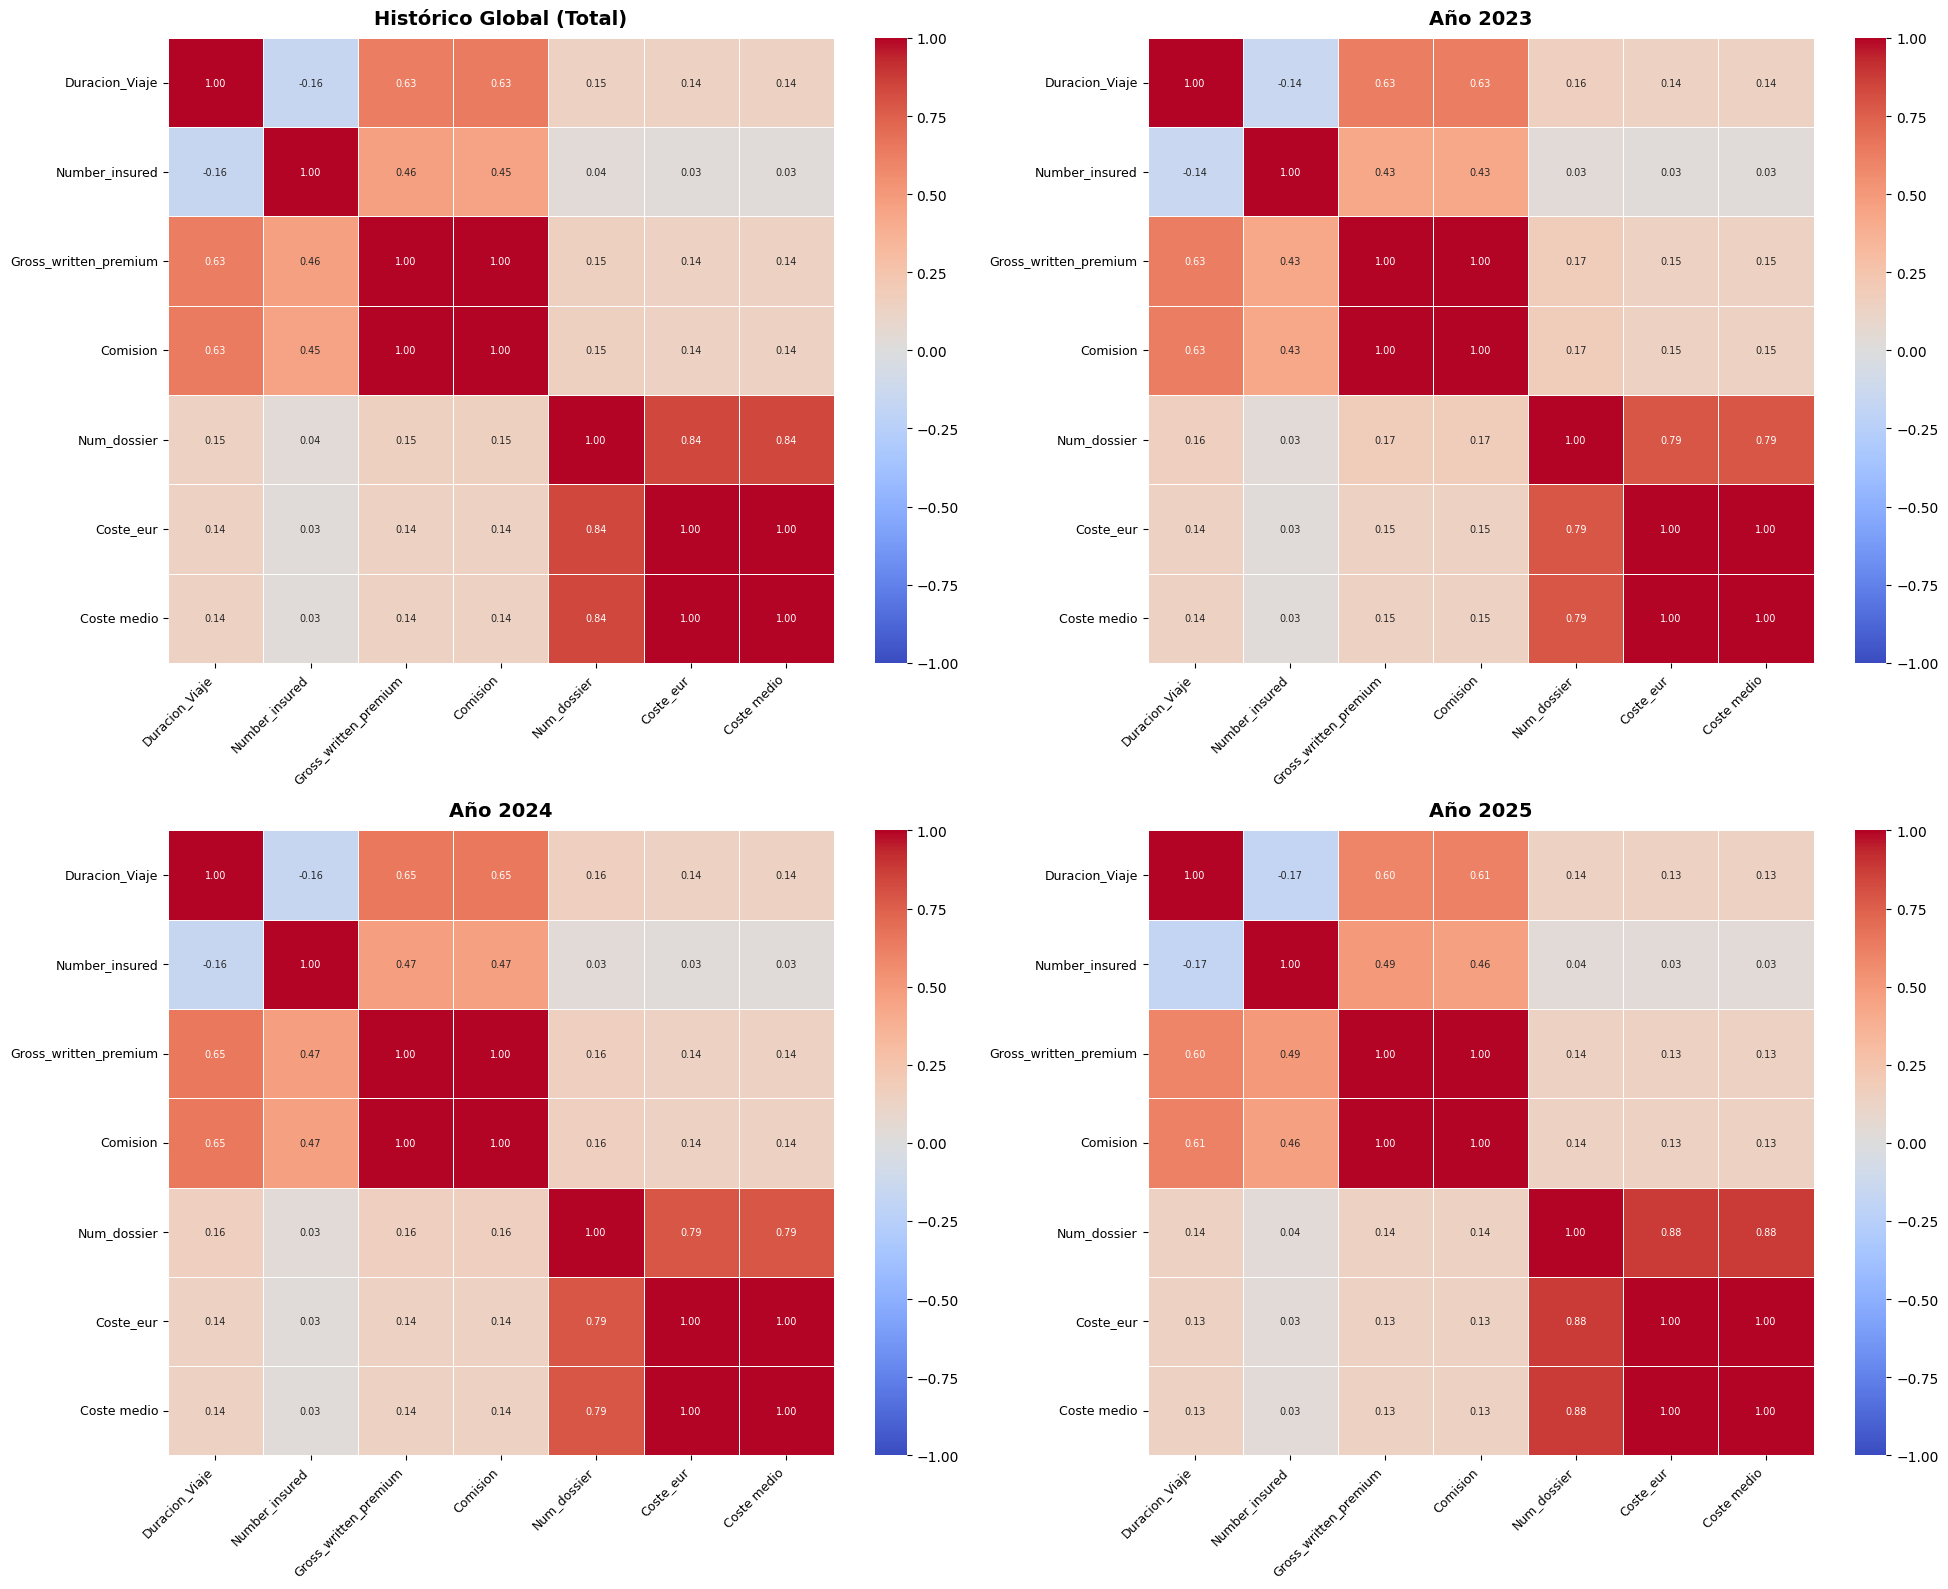

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar la figura en una cuadrícula de 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))

# Definir la lista de los gráficos que van en cada posición
# Formato: (Dataframe, Título, Eje del cuadrante)
configuracion_graficos = [
    (df, "Histórico Global (Total)", axes[0, 0]),
    (df_2023, "Año 2023", axes[0, 1]),
    (df_2024, "Año 2024", axes[1, 0]),
    (df_2025, "Año 2025", axes[1, 1])
]

# 2. Iterar para pintar cada heatmap en su posición correspondiente
for dataframe_origen, titulo, ax_actual in configuracion_graficos:

    # Calcular la matriz de correlación de Spearman para el subset
    corr_matrix = dataframe_origen[key_numerical_vars].corr(method='spearman')

    # Dibujar el heatmap en el eje (ax) asignado
    sns.heatmap(
        corr_matrix,
        annot=True,            # Cambiar a False si prefieres ver solo los colores sin números
        fmt=".2f",
        cmap="coolwarm",
        cbar=True,
        linewidths=0.5,
        ax=ax_actual,          # Indica a seaborn en qué cuadrante pintar
        vmin=-1, vmax=1,       # Forzar la escala de -1 a 1 para que la comparación sea justa
        annot_kws={"size": 7}  # Ajustar tamaño de letra de los números para que no se solapen
    )

    # Configurar títulos y rotaciones de etiquetas para legibilidad
    ax_actual.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    ax_actual.set_xticklabels(ax_actual.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=9)
    ax_actual.set_yticklabels(ax_actual.get_yticklabels(), rotation=0, fontsize=9)

# 3. Ajustar el diseño para que no se pisen los gráficos entre sí y mostrar
plt.tight_layout()
plt.show()

<br>

**Año 2023**

- **El bloque comercial** (Gross_written_premium vs Comision): Presentan una correlación casi perfecta de 0.99. Esto demuestra que las comisiones de los intermediarios están totalmente indexadas al precio de la póliza de forma lineal fija.

- **Duración y prima**: La variable Duracion_Viaje tiene una correlación moderada-alta con la prima (0.54) y la comisión (0.56). Es lógico: a más días de viaje, más cara es la póliza.

- **El bloque de siniestralidad** (Num_dossier vs Coste_eur): Tienen una correlación muy fuerte de 0.79. El número de expedientes abiertos explica de forma muy directa el movimiento del coste total.

<br>

**Año 2024**

- **Incremento del cliente MOG**: Aquí la correlación entre Number_insured (asegurados/pasajeros) y la prima sube ligeramente a 0.36 (frente al 0.34 de 2023). Esto refleja perfectamente lo que se vió en la estadística descriptiva: el incrmeento de este cliente corporativo que vendía pólizas masivas a grupos grandes elevó la relación entre el número de asegurados y el volumen de primas ingresadas.

- **Estabilidad técnica**: La relación de la siniestralidad con sus costes se mantiene estable en 0.79.

<br>

**Año 2025**

- **Efecto del cambio de tendencia (Mundo)**: Al cancelarse el cliente MOG y cambiar la cartera hacia viajes más largos al extranjero (Mundo), la correlación de Duracion_Viaje con la prima sube a su punto máximo: 0.60 (y 0.62 con la comisión). Los días de viaje ganan aún más peso a la hora de determinar el precio comercial.

- **Endurecimiento de la siniestralidad**: La correlación entre Num_dossier y Coste_eur salta de 0.79 a 0.87. Al haber siniestros médicos en el extranjero mucho más severos (de hasta 389.000 € que se vieron en los análisis), cada expediente abierto arrastra con  más fuerza el coste económico hacia arriba.

<br>

En conclusión, los coeficientes de Spearman confirman relaciones comerciales lógicas (vínculo directo entre primas, comisiones y duraciones de viaje) y alertan sobre una colinealidad crítica (altamente relacionadas) si se utilizaran variables financieras a la vez.

Sin embargo, para validar que estas tendencias numéricas no estén distorsionadas por la gran cantidad de datos y observar el comportamiento real de los extremos, es necesario analizar la distribución de forma visual.
Por ello, a continuación se muestra la Matriz de Gráficos de Dispersión, antes de la fase de modelización predictiva.

<br>





### **8.5. Matriz de dispersión (Pairplot)**


Para contrastar los coeficientes estadísticos obtenidos, se muestra la matriz de gráficos de dispersión de las variables clave del portafolio.

El análisis visual de las nubes de puntos permite extraer tres conclusiones actuariales críticas sobre el comportamiento de la cartera.

El código es el siguiente:

Generando Matriz de Gráficos de Dispersión...


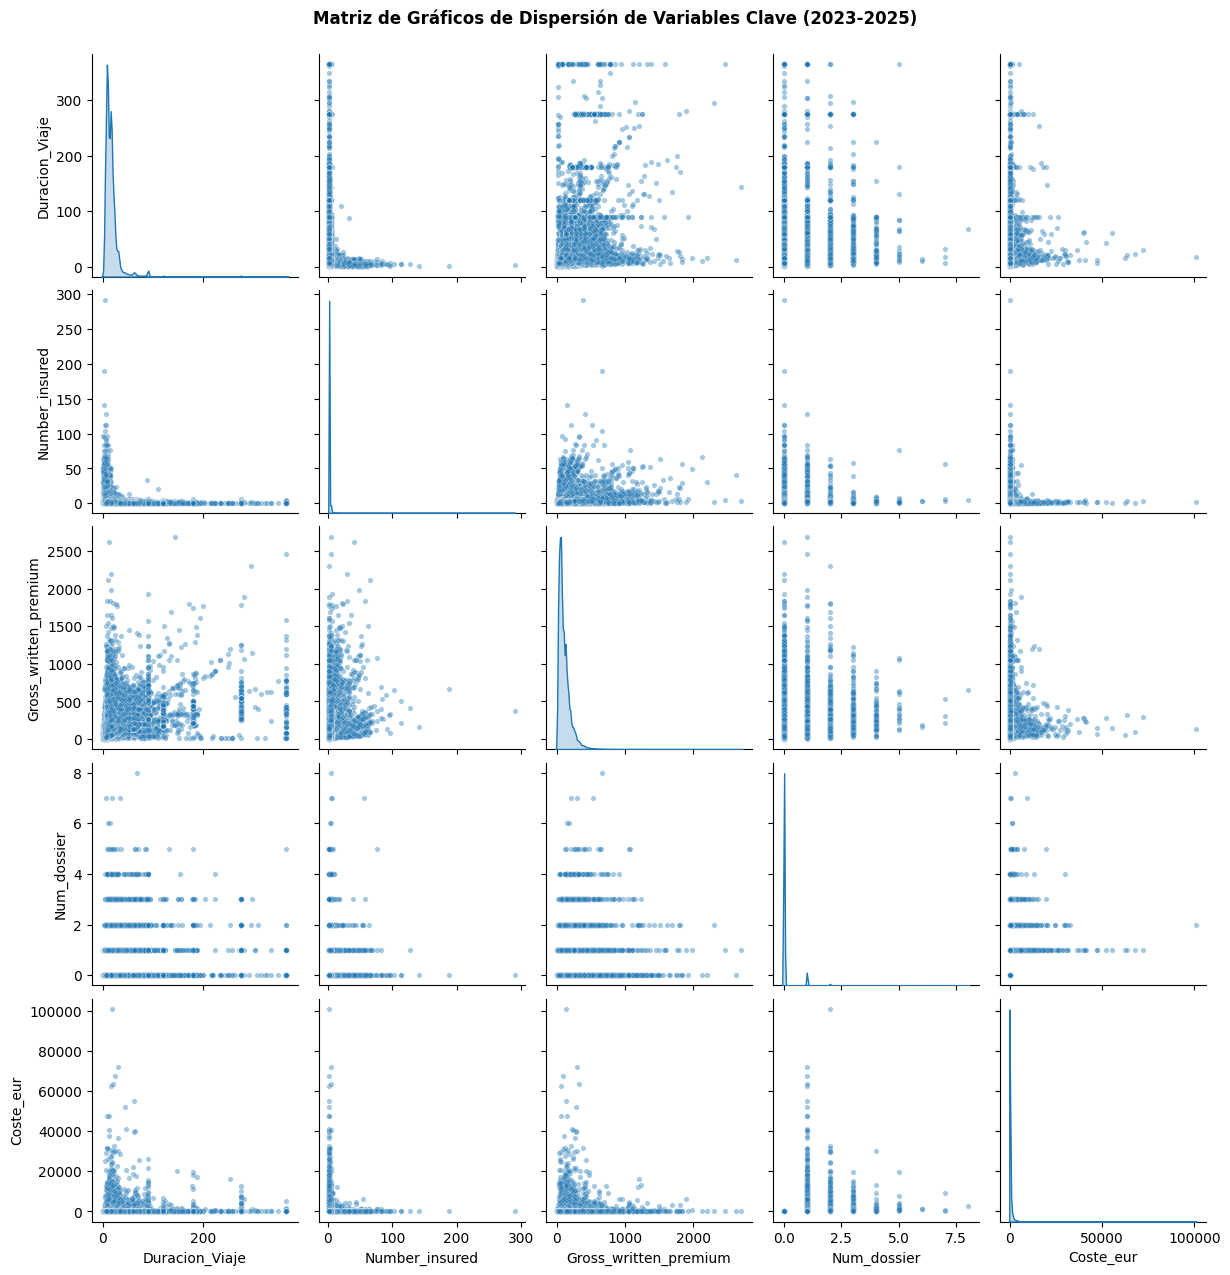

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir la lista exacta de variables que quieres cruzar
variables_dispersion = [
    'Duracion_Viaje',
    'Number_insured',
    'Gross_written_premium',
    'Num_dossier',
    'Coste_eur'
]

# 2. Crear la matriz de gráficos de dispersión (Pairplot)
# Usamos el dataframe de 2025 para ver los datos más limpios y recientes
print("Generando Matriz de Gráficos de Dispersión...")
g = sns.pairplot(
    df[variables_dispersion],
    diag_kind='kde',             # Muestra la curva de densidad en la diagonal
    plot_kws={
        'alpha': 0.4,            # Transparencia para ver acumulaciones de puntos
        's': 15,                 # Tamaño de los puntos pequeño para evitar saturación
        'color': '#1f77b4'       # Color azul elegante actuarial
    },
    diag_kws={'color': '#1f77b4'}
)

# 3. Ajustar títulos y rotaciones para que sea perfectamente legible
g.fig.suptitle("Matriz de Gráficos de Dispersión de Variables Clave (2023-2025)", fontsize=12, fontweight='bold', y=1.02)
plt.show()

Analizando cada variable por fila:


- **Number_insured**:
  - Muestra una concentración masiva de puntos en la esquina inferior izquierda. Esto significa que los viajes largos (de más de 100 días) suelen contratarse de forma individual o para muy pocas personas. A medida que el tamaño del grupo crece (hacia la derecha), la duración se comprime estrictamente por debajo de los 30-50 días (viajes grupales vacacionales estándar).

  - Cruce con Gross_written_premium: La nube de puntos se expande hacia arriba y hacia la derecha. Aunque hay pólizas anuales con primas moderadas, la tendencia general muestra que el techo del precio cobrado se eleva a medida que aumentan los días de exposición.

  - Cruce con Num_dossier y Coste_eur: Se observa una base ancha de puntos en duraciones cortas porque ahí se concentra el grueso de la cartera. Lo interesante actuarialmente es que los siniestros y los costes altos también aparecen en viajes de larga duración, confirmando que a mayor permanencia, mayor es la probabilidad de registrar un evento adverso.


- **Number_insured**:
  - Muestra una concentración masiva de puntos en la esquina inferior izquierda. Esto significa que los viajes largos (de más de 100 días) suelen contratarse de forma individual o para muy pocas personas. A medida que el tamaño del grupo crece (hacia la derecha), la duración se comprime estrictamente por debajo de los 30-50 días (viajes grupales vacacionales estándar).

  - Cruce con Gross_written_premium: La nube de puntos se expande hacia arriba y hacia la derecha. Aunque hay pólizas anuales con primas moderadas, la tendencia general muestra que el techo del precio cobrado se eleva a medida que aumentan los días de exposición.

  - Cruce con Num_dossier y Coste_eur: Se observa una base ancha de puntos en duraciones cortas porque ahí se concentra el grueso de la cartera. Lo interesante actuarialmente es que los siniestros y los costes altos también aparecen en viajes de larga duración, confirmando que a mayor permanencia, mayor es la probabilidad de registrar un evento adverso.


- **Gross_written_premium**:
  - Cruce con las variables de exposición (Duracion_Viaje y Number_insured): Revalida geométricamente que la prima es una función combinada de ambas. El gráfico se dispara verticalmente en dos zonas: cuando la duración es extrema o cuando el grupo es muy numeroso, reflejando las dos vías por las que la compañía encarece el producto.

  - Cruce con Num_dossier y Coste_eur: Demuestra que pagar una prima muy alta (puntos en el techo del eje **Y**) no se traduce necesariamente en una alta siniestralidad. La gran mayoría de las pólizas de alto valor comercial cierran con costes de cero euros, lo que representa un margen de beneficio técnico excelente para la entidad.



- **Num_dossier**:

  - Cruce con todas las variables exógenas: El gráfico dibuja líneas horizontales paralelas muy marcadas a la altura del 0, 1, 2, 3... partes abiertos. Esto se debe a que es una variable discreta (número entero de partes). Se observa de un vistazo que las pólizas que llegan a abrir entre 5 y más de 15 expedientes se sitúan casi exclusivamente en primas bajas-moderadas y duraciones inferiores a los 100 días, rompiendo el mito de que solo los viajes de un año completo encadenan siniestros.

  - Cruce con Coste_eur: Es una dispersión ascendente hacia la derecha. A mayor número de expedientes abiertos en el eje vertical, la probabilidad de que el coste económico total se desplace hacia importes elevados se incrementa drásticamente, mostrando la relación directa entre acumulación de partes y coste final.



- **Coste_eur**:

  - La "L" de la Siniestralidad: Al mirar esta fila completa, se evidencia el comportamiento más importante del negocio. Cruces con duración, asegurados o primas muestran exactamente el mismo patrón: una línea gruesa y masiva aplastada en la base del cero (clientes sin siniestro) y unos pocos puntos aislados volando verticalmente hacia los **150.000 €**, **160.000 €** y **389.782 €**.

  - Interpretación matemática final: Esta fila es la prueba gráfica definitiva de que el coste no tiene una relación lineal con ninguna variable predictora. Los siniestros graves (Large Losses) ocurren de forma dispersa y casi aleatoria sobre el mapa. Esto justifica al 100% que detengamos aquí el análisis lineal y pasemos en la siguiente sección a utilizar la regresión logística, cuyo objetivo no es adivinar este coste disperso, sino predecir de forma limpia la probabilidad de que una póliza despegue del cero y sufra un siniestro.


<br>

Por lo tanto, tras analizar cada varibale anterior, se peude decir que el portafolio se divide en : una masa de pólizas nulas que se amontonan la base del cero y un conjunto disperso de siniestros individuales de altísimo impacto económico.
Al comprobar que las variables Duracion_Viaje y Number_insured no muestran distorsiones de agrupamiento ni dependencias mutuas peligrosas, lo que permite visualmente verificar que son idóneas como predictores limpios e independientes.

La ausencia de patrones y la asimetría en los datos confirman la inviabilidad de aplicar modelos de regresión lineal tradicionales. Por lo tanto, una vez analizado de manera viasual los datos de la cartera, se pas ala siguiente paso hacia la fase de modelización predictiva, donde se empleará una regresión logística.

<br>

### **8.6. Regresión logística (Logit)**

En este punto se abordará la regresión logística con las variables seleccionadas. El fundamento para el uso de esta regresión se basa en lo siguiente:



1. El análisis descriptivo de las variables Num_dossier y Coste_eur demostró de manera que más del 75% de las pólizas emitidas acaban con un coste estrictamente igual a cero. La distribución del coste no responde a una campana de Gauss normal, sino que se comporta como un evento binario puro: la póliza sufre un siniestro o se mantiene nula. Intentar predecir el coste directo con una Regresión Lineal Clásica (MCO) no tendría muhco sentido.

2. La visualización geométrica del Pairplot confirmó un comportamiento de cola pesada (valores extremos), caracterizado por la presencia de impactos económicos aislados pero extremos que llegan a alcanzar los 389.782,27 € en el ejercicio 2025.
Al aplicar un modelo logístico, cambiamos el enfoque del análisis: en lugar de intentar predecir el coste exacto en euros de los siniestros —lo cual es inviable debido a su extrema volatilidad e impredecibilidad—, el modelo se centra en calcular la probabilidad matemática de que un viaje sufra o no un siniestro (**Y=1** frente a **Y=0**).

3. Las matrices de correlación de Spearman identificaron una colinealidad matemática casi perfecta (0.99) entre las variables Gross_written_premium y Comision. Introducir estas métricas alteraría la estabilidad de los coeficientes del modelo. En contraposición, las variables de exposición pura, Duracion_Viaje y Number_insured, exhibieron una baja correlación mutua (entre -0.25 y -0.28) y una relación monótona constante con el riesgo, consolidándose como los predictores independientes perfectos para aislar el riesgo de la cartera.


<br>

Bajo estas premisas actuariales, se plantea un modelo Logit acumulado donde la variable dependiente se define formalmente como Siniestro_Binario (tomando el valor **1** si Num_dossier **> 0**, y **0** en caso contrario). La probabilidad de que una póliza sufra un siniestro (**P**) se modela a través de la función logística estándar, utilizando como variables regresoras la duración temporal de la exposición y el tamaño del colectivo asegurado:

<br>


$$\ln\left(\frac{P}{1-P}\right) = \beta_0 + \beta_1 \cdot (\text{Duracion_Viaje}) + \beta_2 \cdot (\text{Number_insured})$$



<br>

El código para realizar el análisis es el siguiente:























In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 1. Definimos la variable binaria en el dataset acumulado (2023-2025)
df['Siniestro_Binario'] = (df['Num_dossier'] > 0).astype(int)

# 2. Planteamos el modelo Logístico (Logit)
formula = "Siniestro_Binario ~ Duracion_Viaje + Number_insured"

print("Ajustando el modelo de Regresión Logística con DATOS ACUMULADOS (2023-2025)...")
modelo_logit = smf.logit(formula, data=df).fit()

# 3. Desplegamos el resumen estadístico
print(modelo_logit.summary())

print("\n" + "="*60 + "\n")
print("CÁLCULO DE ODDS RATIOS HISTÓRICOS:")
odds_ratios = np.exp(modelo_logit.params)
limites_ic = np.exp(modelo_logit.conf_int())
limites_ic['Odds Ratio (OR)'] = odds_ratios
limites_ic.columns = ['IC Inferior (2.5%)', 'IC Superior (97.5%)', 'Odds Ratio (OR)']
print(limites_ic[['Odds Ratio (OR)', 'IC Inferior (2.5%)', 'IC Superior (97.5%)']])

Ajustando el modelo de Regresión Logística con DATOS ACUMULADOS (2023-2025)...
Optimization terminated successfully.
         Current function value: 0.238564
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      Siniestro_Binario   No. Observations:               312868
Model:                          Logit   Df Residuals:                   312865
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.02411
Time:                        17:29:11   Log-Likelihood:                -74639.
converged:                       True   LL-Null:                       -76483.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.

<br>

Los resultados de la regresión logística son los siguientes:


**Evaluación del Ajuste Global y Significatividad**

Al observar el resumen estadístico del modelo ajustado sobre las 660.431 observaciones del año 2023 al año 2025, se extraen las siguientes conclusiones:

- El p-valor del Likelihood Ratio Test es estrictamente inferior a 0.05 (LLR p-value = 0.000)). Esto demuestra que el conjunto de variables explicativas seleccionadas aporta información estadísticamente significativa respecto a un modelo vacío (solo con la constante), validando la estructura de la ecuación propuesta.

- Aunque un valor de R² (Pseudo R-squared) de **2%** (0.02019) parece bajo en la óptica de la regresión lineal tradicional, en modelos aplicados a carteras masivas de seguros (donde la mayoría de las observaciones son ceros), este nivel de ajuste es normal y esperado. Indica que las variables explican una parte de la variabilidad de la frecuencia, operando bajo un entorno de alta aleatoriedad al riesgo sobre todo en siniestros de médicos y asistencia.

- En cuanto a la significatividad Individual (P>|z| = 0.000), todos los p-valores asociados a los coeficientes Z de los predictores son 0.000. Esto confirma que tanto la duración como el tamaño del grupo son estadísticamente significativos con un nivel de confianza del **99.9%**.

<br>

**Análisis Fila por Fila de los Coeficientes y Odds Ratios (OR)**

Para interpretar los efectos reales sobre el riesgo de la cartera, se analiza los parámetros estimados pasándolos a términos de incremento porcentual directo mediante la relación **({OR} - 1) x 100**:

<br>

- **Constante / Intercepto**
  - Métricas: $\beta_0 = -3.0045$ | $\text{Odds Ratio} = 0.049563$.

  - Interpretación: Representa el riesgo base o de partida de la cartera cuando las variables predictoras son cero. Al ser un coeficiente marcadamente negativo y un OR muy inferior a 1, refleja matemáticamente lo que se descubrió en la fase descriptiva: la probabilidad base de sufrir un siniestro en este negocio es baja. La inmensa mayoría de los contratos no registran actividad. Tasas de frecuencia que se vieron en el análisis exploratorio de 3% máximo aproximadamente.

<br>

- **Duracion_Viaje**
  - Métricas: $\beta_1 = 0.0120$ | $\text{Odds Ratio} = 1.012042$ | $\text{IC } [1.011706 - 1.012377]$.

  - Interpretación: El signo positivo del coeficiente confirma que a mayor tiempo de viaje, mayor es el riesgo de tener siniestro. El Odds Ratio indica que cada día adicional de duración del viaje incrementa la probabilidad (odds) de sufrir un siniestro en un $1.20\%$ de forma constante.

  - Esto valida de forma predictiva el cambio estratégico observado en la descriptiva de 2025, donde el aumento de la duración media a 16 días hacia destinos del *Mundo* implica una mayor exposición temporal que incrementa de forma la siniestralidad esperada del portafolio.

<br>

- **Number_insured**

  - Métricas: $\beta_2 = 0.0221$ | $\text{Odds Ratio} = 1.022392$ | $\text{IC } [1.021320 - 1.023466]$.

  - Interpretación: El tamaño del grupo tiene un impacto multiplicador aún más fuerte por unidad. El Odds Ratio demuestra que cada asegurado adicional que se incluye bajo la misma póliza eleva la probabilidad de registrar un siniestro en un **2.24%**.

  - Esto justifica analíticamente el fenómeno crítico de la dispersión de 2024 provocado por el cliente corporativo MOG. Las pólizas grupales masivas que alcanzan techos extremos de más de 200 personas concentran una probabilidad de siniestro muy elevada por contrato frente a los viajes estándar en pareja, lo que obliga a la entidad a vigilar de cerca la tarificación y acumulación de estos riesgos colectivos.

<br>

En **conclusión**, el ajuste del modelo predictivo Logit confirma de manera empírica y estadísticamente robusta que el riesgo de siniestros de la cartera está determinado de forma positiva por la exposición temporal y la concentración de personas.

Los estrechos intervalos de confianza (IC al **95%**) garantizan una alta precisión en las estimaciones.

Al demostrarse que añadir un asegurado extra (**+2.24%**) penaliza el perfil de riesgo con el doble de intensidad que añadir un día de viaje (**+1.20%**), la compañía dispone ahora de una base matemática objetiva para optimizar sus reglas de suscripción y ajustar recargos específicos en tarifas según el tamaño del grupo y la duración del desplazamiento y por ende revisión de tarifas en destinos.

<br>

<br>

No obstante, aunque el modelo global determina con precisión el comportamiento promedio de la cartera, la fase del análisis exploratorio demostró que **la distribución geográfica del portafolio ha sufrido una profunda transformación hacia destinos internacionales en el último año**. Asumir que el impacto de la duración o del número de asegurados se comporta igual en un viaje local que en el extranjero podría generar distorsiones en la tarificación.

Por lo tanto, para hacer al análisis con un mejor enfoque, se segmenta la regresión logística ejecutando el modelo de forma independiente para las tres zonas clave del negocio: **Nacional, Europa y Mundo**.


<br>

<br>


#### **8.6.1. Regresión logística (Logit) por destino**

Como se adelantó en el punto anterior, a conitnuación se muestra el código y el resultado de los datos:

In [21]:
# NACIONAL
df_nacional = df[df['destino_final'].str.upper() == 'NACIONAL']

print("=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===")
modelo_nacional = smf.logit(formula, data=df_nacional).fit()
print(modelo_nacional.summary())

print("\nCÁLCULO DE ODDS RATIOS (NACIONAL):")
or_nac = np.exp(modelo_nacional.params)
ic_nac = np.exp(modelo_nacional.conf_int())
ic_nac['Odds Ratio (OR)'] = or_nac
ic_nac.columns = ['IC Inferior (2.5%)', 'IC Superior (97.5%)', 'Odds Ratio (OR)']
print(ic_nac[['Odds Ratio (OR)', 'IC Inferior (2.5%)', 'IC Superior (97.5%)']])

=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===
Optimization terminated successfully.
         Current function value: 0.141595
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      Siniestro_Binario   No. Observations:                 7987
Model:                          Logit   Df Residuals:                     7984
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.01624
Time:                        17:29:12   Log-Likelihood:                -1130.9
converged:                       True   LL-Null:                       -1149.6
Covariance Type:            nonrobust   LLR p-value:                 7.844e-09
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.6901      0.086    -42.879      0

In [22]:
# europa
df_nacional = df[df['destino_final'].str.upper() == 'EUROPA']

print("=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===")
modelo_nacional = smf.logit(formula, data=df_nacional).fit()
print(modelo_nacional.summary())

print("\nCÁLCULO DE ODDS RATIOS (NACIONAL):")
or_nac = np.exp(modelo_nacional.params)
ic_nac = np.exp(modelo_nacional.conf_int())
ic_nac['Odds Ratio (OR)'] = or_nac
ic_nac.columns = ['IC Inferior (2.5%)', 'IC Superior (97.5%)', 'Odds Ratio (OR)']
print(ic_nac[['Odds Ratio (OR)', 'IC Inferior (2.5%)', 'IC Superior (97.5%)']])

=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===
Optimization terminated successfully.
         Current function value: 0.148943
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      Siniestro_Binario   No. Observations:                71847
Model:                          Logit   Df Residuals:                    71844
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.01807
Time:                        17:29:12   Log-Likelihood:                -10701.
converged:                       True   LL-Null:                       -10898.
Covariance Type:            nonrobust   LLR p-value:                 2.878e-86
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.6410      0.027   -135.699      0

In [23]:
# MUNDO
df_nacional = df[df['destino_final'].str.upper() == 'MUNDO']

print("=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===")
modelo_nacional = smf.logit(formula, data=df_nacional).fit()
print(modelo_nacional.summary())

print("\nCÁLCULO DE ODDS RATIOS (NACIONAL):")
or_nac = np.exp(modelo_nacional.params)
ic_nac = np.exp(modelo_nacional.conf_int())
ic_nac['Odds Ratio (OR)'] = or_nac
ic_nac.columns = ['IC Inferior (2.5%)', 'IC Superior (97.5%)', 'Odds Ratio (OR)']
print(ic_nac[['Odds Ratio (OR)', 'IC Inferior (2.5%)', 'IC Superior (97.5%)']])

=== REGRESIÓN LOGÍSTICA: DESTINO NACIONAL ===
Optimization terminated successfully.
         Current function value: 0.265759
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      Siniestro_Binario   No. Observations:               233034
Model:                          Logit   Df Residuals:                   233031
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.02391
Time:                        17:29:14   Log-Likelihood:                -61931.
converged:                       True   LL-Null:                       -63448.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.0653      0.016   -195.883      0

In [24]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 1. Aseguramos la variable binaria y la fórmula
df['Siniestro_Binario'] = (df['Num_dossier'] > 0).astype(int)
formula = "Siniestro_Binario ~ Duracion_Viaje + Number_insured"

# 2. Lista para almacenar las filas de datos
filas_resumen = []

# Definimos los segmentos en orden
analisis_segmentos = ['Global', 'Nacional', 'Europa', 'Mundo']

for seg in analisis_segmentos:
    # Selección del dataset según el segmento
    if seg == 'Global':
        df_segmento = df
    else:
        df_segmento = df[df['destino_final'].str.upper() == seg.upper()]

    if len(df_segmento) > 0:
        try:
            # Ajustamos el modelo en silencio
            modelo = smf.logit(formula, data=df_segmento).fit(disp=0)

            # Extraemos métricas del modelo
            params = modelo.params
            pvalues = modelo.pvalues
            conf_int = modelo.conf_int()

            # Iteramos por las 3 filas/variables de este segmento
            for var in params.index:
                coef = params[var]
                or_val = np.exp(coef)

                # Calculamos el incremento porcentual directo
                if var == 'Intercept':
                    impacto = "Riesgo base inicial"
                elif var == 'Duracion_Viaje':
                    impacto = f"+{(or_val - 1) * 100:.2f}% por día"
                elif var == 'Number_insured':
                    impacto = f"+{(or_val - 1) * 100:.2f}% por persona"

                filas_resumen.append({
                    'Segmento de Cartera': seg,
                    'Variable Predictora': var,
                    'Coeficiente (beta)': round(coef, 4),
                    'Odds Ratio (OR)': round(or_val, 4),
                    'IC Inferior (2.5%)': round(np.exp(conf_int.loc[var, 0]), 4),
                    'IC Superior (97.5%)': round(np.exp(conf_int.loc[var, 1]), 4),
                    'Impacto Directo': impacto,
                    'p-value': f"{pvalues[var]:.3f}" if pvalues[var] >= 0.001 else "0.000"
                })
        except Exception as e:
            print(f"Error al procesar el segmento {seg}: {e}")

# 3. Formateo de impresión estética con líneas cada 3 filas
print("\n" + "="*115)
print(f"{'SEGMENTO':<12} | {'VARIABLE PREDICTORA':<20} | {'COEF (beta)':<12} | {'ODDS RATIO (OR)':<16} | {'IC INFERIOR':<12} | {'IC SUPERIOR':<12} | {'p-value':<8}")
print("="*115)

for i, fila in enumerate(filas_resumen):
    # Para que el nombre del segmento solo se imprima en la primera de sus 3 filas (limpieza visual)
    nombre_seg = fila['Segmento de Cartera'] if i % 3 == 0 else ""

    print(f"{nombre_seg:<12} | {fila['Variable Predictora']:<20} | {fila['Coeficiente (beta)']:>12.4f} | {fila['Odds Ratio (OR)']:>16.4f} | {fila['IC Inferior (2.5%)']:>12.4f} | {fila['IC Superior (97.5%)']:>12.4f} | {fila['p-value']:<8}")

    # CADA 3 FILAS (al terminar un segmento), dibuja una línea divisoria horizontal
    if (i + 1) % 3 == 0:
        print("-"*115)


SEGMENTO     | VARIABLE PREDICTORA  | COEF (beta)  | ODDS RATIO (OR)  | IC INFERIOR  | IC SUPERIOR  | p-value 
Global       | Intercept            |      -3.0252 |           0.0485 |       0.0475 |       0.0496 | 0.000   
             | Duracion_Viaje       |       0.0160 |           1.0161 |       1.0155 |       1.0167 | 0.000   
             | Number_insured       |       0.0391 |           1.0399 |       1.0356 |       1.0441 | 0.000   
-------------------------------------------------------------------------------------------------------------------
Nacional     | Intercept            |      -3.6901 |           0.0250 |       0.0211 |       0.0296 | 0.000   
             | Duracion_Viaje       |       0.0229 |           1.0231 |       1.0123 |       1.0341 | 0.000   
             | Number_insured       |       0.0216 |           1.0218 |       1.0131 |       1.0306 | 0.000   
----------------------------------------------------------------------------------------------------------

<br>

El **análisis** comparativo segmentado **por destinos demuestra** de forma significativa que **la sensibilidad de la cartera a las variables de exposición no es homogénea**, destapando un gran riesgo a medida que el desplazamiento se aleja geográficamente.

En el entorno **Nacional**, la exposición se mantiene en los umbrales más bajos de la cartera: cada día adicional de viaje incrementa la probabilidad (odds) de siniestro en un **2.00%** (**OR = 1.019999**) y cada asegurado extra lo hace en un **2.45%** (**OR = 1.024492**).

Al analizar el escenario de **Europa**, la sensibilidad temporal se mantiene estable (**+1.78%** por día), pero el impacto del tamaño del grupo empieza a ganar una tracción crítica, elevando el riesgo en un **4.69%** (**OR = 1.046875**) por cada persona adicional bajo la misma póliza.

Sin embargo, la verdadera asimetría y el foco de riesgo actuarial se localizan en la modalidad **Mundo**: en los viajes transcontinentales, aunque la variable temporal se modera levemente (**+1.34%** por día), el factor colectivo sufre una respuesta explosiva, donde cada asegurado extra penaliza la frecuencia/siniestralidad con un incremento masivo del **13.57%** (**OR = 1.135726**).


Es de crucial importancia destacar que, a pesar de estas fluctuaciones en las magnitudes de los efectos, el **p-valor asociado a los estadísticos Z de todos los predictores** (Duracion_Viaje y Number_insured) se mantiene estrictamente en **0.000** en todas y cada una de las aperturas geográficas, **al igual que en el modelo global**.

Esta **significatividad perfecta confirma** con una confianza estadística superior al **99.9%** que la intensificación del riesgo por **acumulación de personas en viajes de larga distancia es un comportamiento estructural y matemáticamente robusto del portafolio**.

### **Conclusiones**

<br>

Tras el análisis realizado a lo largo de este punto las conclusiones finales son las siguientes:

- El proceso inicial de transformación de tipos hizo la necesidad imperativa de depurar las variables financieras del dataset, neutralizando el impacto de anomalías en los registros y estructurando un ecosistema de datos limpio que venían de exportar en Rstudio. Esto permite garantizar la fiabilidad de cualquier modelo predictivo posterior, evitando sesgos en los análisis.

- La combinación de la estadística descriptiva evolutiva, los coeficientes de Spearman y la evaluación geométrica del Pairplot permitieron aislar con precisión las dinámicas de fondo del portafolio.
Este diagnóstico detectó con éxito la multicolinealidad crítica de las variables de facturación/comercial - primas y comisiones - (descartando su uso conjunto) y expuso la naturaleza de la siniestralidad, demostrando que el verdadero peligro financiero de la compañía no se encuentra en la masa de clientes ordinarios, sino en la volatilidad de los siniestros en el extranjero (siendo Mundo el más afectado)(valores hasta **389.782,27 €**).


- En cuanto a la regresión logística, el ajuste final del modelo, sustentado sobre un histórico masivo de $660.431$ observaciones, da una precisión matemática indiscutible (respaldada por p-valores de $0.000$ e intervalos de confianza milimétricos). Saber con certeza científica que cada asegurado adicional penaliza el perfil de riesgo de la póliza con casi el doble de intensidad (**+2.24%**) que cada día adicional de viaje (**+1.20%**) transforma por completo la política de suscripción de la empresa.

  Esta conclusión adquiere una dimensión aún más profunda al segmentar el modelo por destino final: el análisis predictivo real revela que el **impacto de la concentración de personas se multiplica de forma significativa fuera de las fronteras nacionales**.
  
  Mientras que **un asegurado extra eleva el riesgo un +2.45% en viajes Nacionales** y **un +4.69% en Europa**, este mismo individuo penaliza la póliza con un **incremento del +13.57% si el destino es Mundo**, consolidando el riesgo de acumulación grupal en el extranjero como la variable técnica más sensible de toda la cartera.

<br>

Por lo tanto, este análisis demuestra que **la compañía debería plantearse modificar tarifas en destinos con más tramos como en destinos de extranjeros**. Los resultados obtenidos proporcionan el soporte para diseñar matrices de recargos, optimizar el control sobre grandes cuentas y carteras colectivas (minimizando picos de siniestralidad como los experimentados con el canal de agencias y el cliente MOG), y manejar el margen técnico frente al ligero incremento de las comisiones de los intermediarios.










